In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [4]:
# Image transformations (important for pretrained models)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2 input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Dataset (example: Cats vs Dogs folder structure)
train_data = datasets.ImageFolder('data/train', transform=transform)
test_data = datasets.ImageFolder('data/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

num_classes = len(train_data.classes)

In [5]:
model = models.mobilenet_v2(pretrained=True)

/Users/rayyansiddiqui/.pyenv/versions/nbenv-3.13.1/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rayyansiddiqui/.pyenv/versions/nbenv-3.13.1/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/rayyansiddiqui/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100.0%


In [6]:
for param in model.parameters():
    param.requires_grad = False

In [7]:
# Replace final layer
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

In [10]:
criterion = nn.CrossEntropyLoss()

# Only train classifier parameters
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [11]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.3604
Epoch [2/5], Loss: 0.1675
Epoch [3/5], Loss: 0.1473
Epoch [4/5], Loss: 0.1096
Epoch [5/5], Loss: 0.1064


In [12]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.50%


In [13]:
import matplotlib.pyplot as plt
import numpy as np

In [14]:
def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)

In [15]:
class_names = train_data.classes
print(class_names)   # ['cats', 'dogs']

['cats', 'dogs']


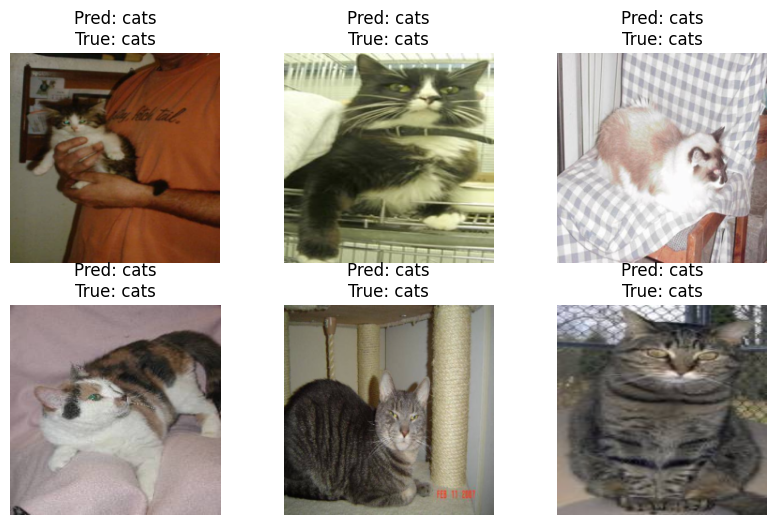

In [17]:
model.eval()

images_shown = 0
max_images = 6

plt.figure(figsize=(10, 6))

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        for i in range(images.size(0)):
            images_shown += 1
            
            plt.subplot(2, 3, images_shown)
            imshow(images[i])
            
            true_label = class_names[labels[i]]
            pred_label = class_names[preds[i]]
            
            plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
            plt.axis("off")
            
            if images_shown == max_images:
                plt.show()
                break
        
        if images_shown == max_images:
            break